# Make predictions

In [1]:
import sys
import os
from pprint import pprint

project_root = os.path.abspath("../")  # one level up from notebook/

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pension_model.predictor import TimeSeriesPredictor

import pandas as pd

## Load pretrained model

In [2]:
# Create a new predictor instance
new_predictor = TimeSeriesPredictor()

# Load the saved model
success = new_predictor.load_model("../models/production_model_v1")
if success:
    print("Model loaded successfully!")

INFO:pension_model.predictor: Model loaded from ..\models\production_model_v1\model.pkl
INFO:pension_model.predictor: Preprocessing pipeline loaded from ..\models\production_model_v1\preprocessing_pipeline.pkl
INFO:pension_model.predictor:Metadata loaded from ..\models\production_model_v1\metadata.json
INFO:pension_model.predictor:Model loading completed successfully


Model loaded successfully!


In [3]:
# Check what data is needed for predictions
requirements = new_predictor.get_prediction_requirements()
print("\nPrediction requirements:\n")
pprint(requirements)


Prediction requirements:

{'feature_engineering_applied': {'lag_periods': [1, 9],
                                 'rolling_windows': [3, 6]},
 'max_lag_required': 9,
 'minimum_rows_needed': 9,
 'required_base_columns': ['Annee',
                           'D_PIB',
                           'PROD',
                           'CHO',
                           'MI',
                           'FEC',
                           'ESP_F',
                           'ESP_H',
                           'PIB_VAL',
                           'PRELEV_REF',
                           'CONTRIB_REF',
                           'PIB_VOL'],
 'total_features_created_and_selected': 20}


In [4]:
print('Info Model:')
new_predictor.best_model

Info Model:


,family,'gamma'
,link,'log'
,alpha,0.0
,fit_intercept,True


## Import data

In [5]:
dtypes = {
    "Annee": "int64",
    "D_PIB": "float64"
}

raw_df = pd.read_csv("../data/dataset_COR_norm.csv", index_col=False, dtype=dtypes)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains("^Unnamed")]

In [6]:
# Check if the length is a multiple of 69
n_years = 69
assert len(raw_df) % n_years == 0, "Data length must be a multiple of 69"

# Create dictionary of DataFrames
grouped_dfs = {
    f"scenario_{i}": raw_df.iloc[i*n_years:(i+1)*n_years].reset_index(drop=True)
    for i in range(len(raw_df) // n_years)
}

## Make predictions

In [7]:
actual = {}
predictions_multi = {}

for idx in range(8):

    # Show the selected scenario
    selected_scenario = 'scenario_' + str(idx)
    
    # Data used for prediction
    new_data = grouped_dfs[selected_scenario] 
    actual[selected_scenario] = new_data['D_PIB']
    predictions_multi[selected_scenario] = new_predictor.predict_new_data(new_data)

years = new_data['Annee']

INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data validation passed
INFO:pension_model.predictor: Predictions completed for 69 samples
INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data validation passed
INFO:pension_model.predictor: Predictions completed for 69 samples
INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data validation passed
INFO:pension_model.predictor: Predictions completed for 69 samples
INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data validation passed
INFO:pension_model.predictor: Predictions completed for 69 samples
INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data validation passed
INFO:pension_model.predictor: Predictions completed for 69 samples
INFO:pension_model.predictor: Predicting on 69 samples
INFO:pension_model.predictor: Input data

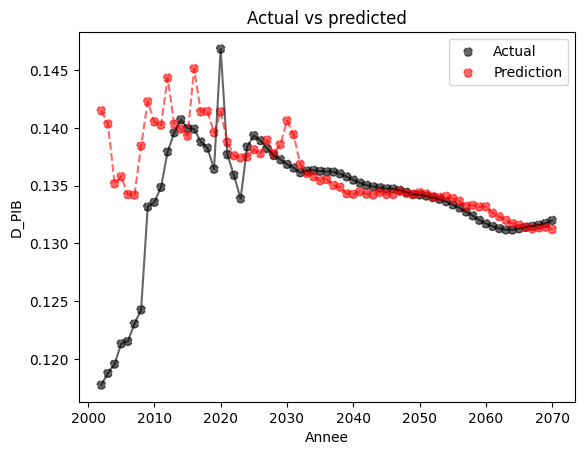

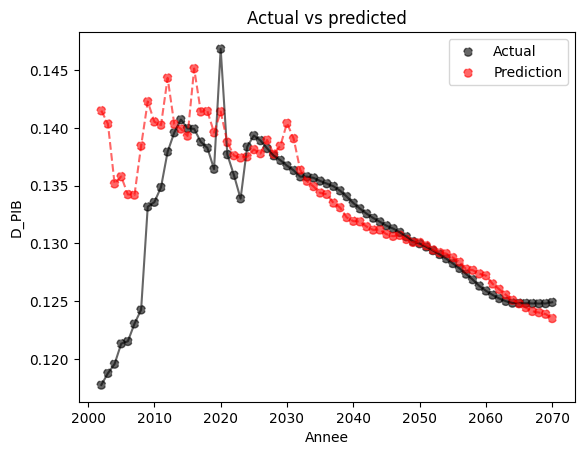

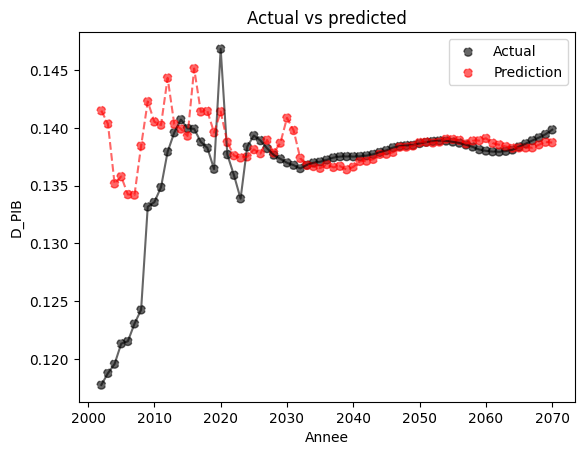

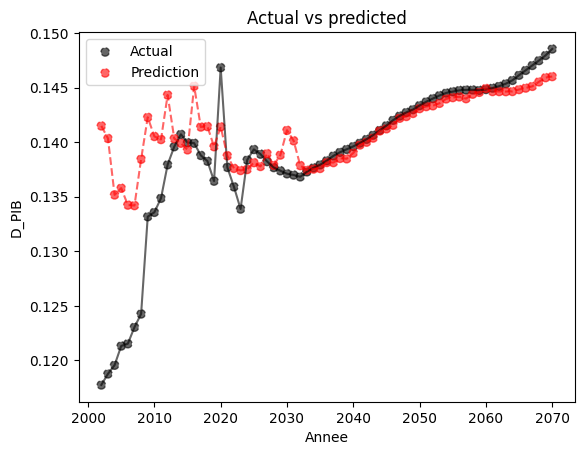

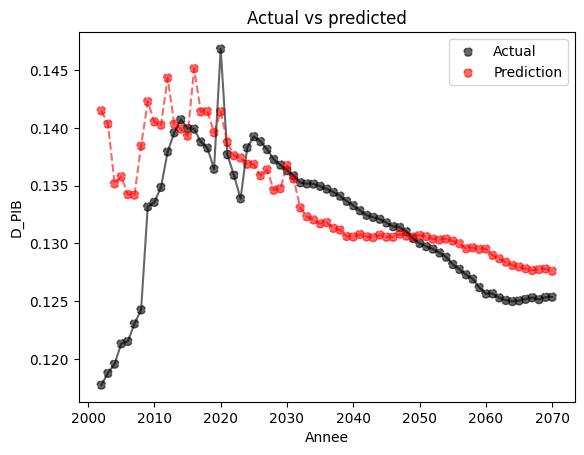

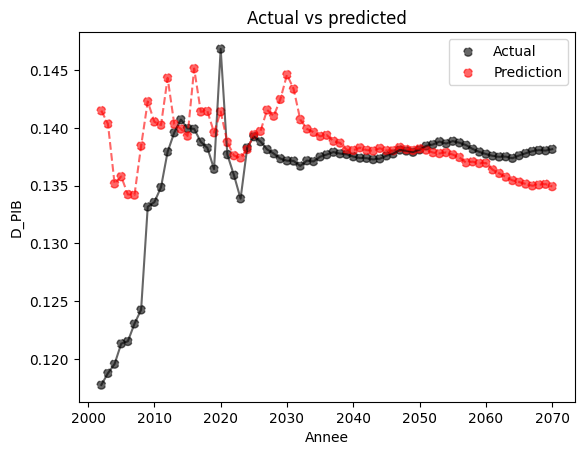

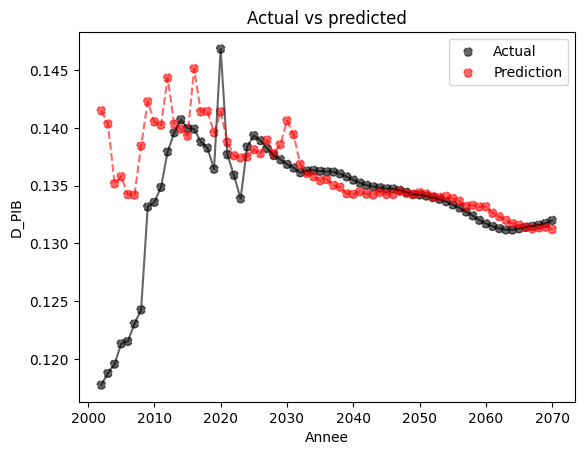

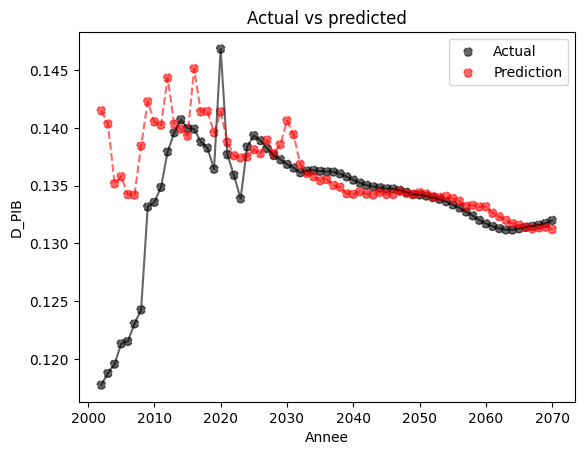

In [8]:
# Plot
import matplotlib.pyplot as plt
import seaborn as sns

for idx in range(8):

    # Show the selected scenario
    selected_scenario = 'scenario_' + str(idx)

    plt.figure()
    plt.scatter(years, actual[selected_scenario], alpha=0.6, color='black', linestyle='--', label='Actual')
    plt.plot(years, actual[selected_scenario], alpha=0.6, color='black', linestyle='-')
    plt.scatter(years, predictions_multi[selected_scenario], alpha=0.6, color='r', linestyle='--', label='Prediction')
    plt.plot(years, predictions_multi[selected_scenario], alpha=0.6, color='r', linestyle='--')

    plt.legend()
    plt.gca().set_xlabel('Annee')
    plt.gca().set_ylabel('D_PIB')
    plt.gca().set_title('Actual vs predicted')

---
---